# 🤖 IEEE-CIS Fraud Detection — Basic Model Training

> **Input:** `data/balanced_train.csv` — SMOTE-balanced dataset from preprocessing.  
> **Goal:** Train three baseline classifiers, evaluate each independently, then compare side-by-side.

### Models in this notebook

| # | Model | Type | Why include it |
|---|-------|------|----------------|
| 1 | Logistic Regression | Linear classifier | Linear baseline — sets the floor |
| 2 | Random Forest | Ensemble (bagging) | Robust non-linear baseline |
| 3 | XGBoost | Gradient boosting | Industry-standard for tabular fraud detection |

Each model is **trained on the same split**, **evaluated with the same metrics**, and **plotted on the same comparison chart** — giving you a clean apples-to-apples comparison for your report.

### Evaluation metrics used
- **Accuracy** — overall correctness (note: misleading for imbalanced data)
- **F1-Score (macro)** — harmonic mean of precision & recall, robust to imbalance
- **ROC-AUC** — area under the receiver operating characteristic curve
- **Confusion Matrix** — visualises true/false positives and negatives
- **Classification Report** — precision, recall, F1 per class

## ⚙️ 0 — Setup: Imports, Paths & Style

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(BASE_DIR, 'data')
FIG_DIR   = os.path.join(BASE_DIR, 'reports', 'figures', 'basic_models')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Dark-mode style ───────────────────────────────────────────────────────────
BG = '#0F1117'; FRAUD = '#E74C3C'; LEGIT = '#4A90D9'
ACCENT = '#F39C12'; TEXT = '#EAEAEA'; GRID = '#2A2D3E'
COLORS = ['#4A90D9', '#F39C12', '#E74C3C']  # LR, RF, XGB
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': GRID, 'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT, 'xtick.color': TEXT,
    'ytick.color': TEXT, 'text.color': TEXT,
    'legend.facecolor': '#1A1D2E', 'legend.edgecolor': GRID,
    'font.size': 11, 'axes.titlesize': 13,
})
def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=150, facecolor=BG)
    print(f'  Saved → reports/figures/basic_models/{name}')
    plt.show()
print('Setup complete.')

Setup complete.


## 📂 1 — Load Data & Train/Test Split

### What
Load `balanced_train.csv` (SMOTE-balanced, 50/50 fraud:legit) and split into an 80/20 stratified train/test set.

### Why
- **Stratified split** preserves the 50/50 class ratio in both train and test halves.
- `random_state=42` ensures reproducibility — every run produces the same split.
- We apply `StandardScaler` so Logistic Regression (which is sensitive to feature scale) is on equal footing with tree-based models.

In [2]:
print('Loading balanced_train.csv ...')
df = pd.read_csv(os.path.join(DATA_DIR, 'balanced_train.csv'))
print(f'Shape : {df.shape}')
print(df['isFraud'].value_counts().rename_axis('isFraud').reset_index(name='count'))

TARGET = 'isFraud'
DROP   = ['TransactionID', 'TransactionDT']  # ID & raw time — not features
X = df.drop(columns=[TARGET] + [c for c in DROP if c in df.columns])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler  = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

print(f'\nTrain : {X_train.shape}  |  Test : {X_test.shape}')

Loading balanced_train.csv ...
Shape : (341925, 361)
   isFraud   count
0        0  227950
1        1  113975

Train : (273540, 359)  |  Test : (68385, 359)


## 🔧 Helper — Evaluation & Plotting Functions

In [3]:
results_store = {}  # collects metrics for all models

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, color):
    """Fit, evaluate, and plot an individual classifier."""
    print(f'Training {name} ...')
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='macro')
    auc  = roc_auc_score(y_te, y_proba)
    cm   = confusion_matrix(y_te, y_pred)
    fpr, tpr, _ = roc_curve(y_te, y_proba)

    results_store[name] = {'acc': acc, 'f1': f1, 'auc': auc, 'fpr': fpr, 'tpr': tpr}

    print(f'  Accuracy : {acc:.4f}  |  F1 (macro) : {f1:.4f}  |  ROC-AUC : {auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Legitimate', 'Fraudulent']))

    # ── Confusion matrix plot
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
                linewidths=0.5, linecolor=GRID, cbar=False)
    ax.set_title(f'Confusion Matrix — {name}', pad=10)
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    fig.tight_layout()
    savefig(fig, f'cm_{name.replace(" ", "_").lower()}.png')

    return model

print('Helper functions defined.')

Helper functions defined.


## 📏 Model 1 — Logistic Regression

### What
A linear probabilistic classifier that fits a hyperplane to separate fraud from legitimate transactions.

### Why include it
Logistic Regression is the **canonical linear baseline** in fraud detection. If it performs poorly, it confirms the data has non-linear fraud boundaries that require more expressive models. Its **coefficients are directly interpretable** — you can read off which features push toward fraud vs. legit.

Training Logistic Regression ...
  Accuracy : 0.8148  |  F1 (macro) : 0.7940  |  ROC-AUC : 0.8785
              precision    recall  f1-score   support

  Legitimate       0.87      0.85      0.86     45590
  Fraudulent       0.71      0.75      0.73     22795

    accuracy                           0.81     68385
   macro avg       0.79      0.80      0.79     68385
weighted avg       0.82      0.81      0.82     68385

  Saved → reports/figures/basic_models/cm_logistic_regression.png


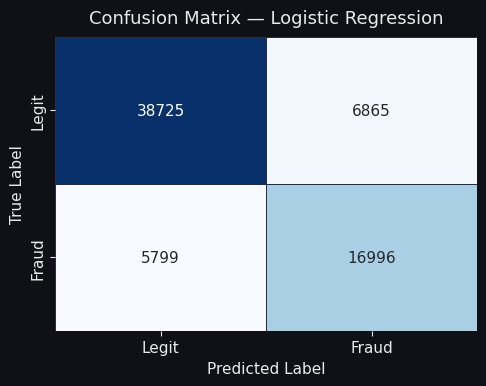

In [4]:
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                         class_weight='balanced', random_state=42)
lr = evaluate_model('Logistic Regression', lr, Xs_train, Xs_test, y_train, y_test, COLORS[0])

## 🌳 Model 2 — Random Forest Classifier

### What
An ensemble of independently trained decision trees that vote on the final prediction (bagging).

### Why include it
- **Handles non-linear boundaries** that Logistic Regression cannot.
- **Robust to outliers and correlated features** — ideal for the messy V-features in this dataset.
- Provides **built-in feature importance** scores, valuable for report analysis.
- Acts as the **robust non-linear baseline** that XGBoost will be compared against.

Training Random Forest ...
  Accuracy : 0.9434  |  F1 (macro) : 0.9358  |  ROC-AUC : 0.9762
              precision    recall  f1-score   support

  Legitimate       0.95      0.97      0.96     45590
  Fraudulent       0.93      0.90      0.91     22795

    accuracy                           0.94     68385
   macro avg       0.94      0.93      0.94     68385
weighted avg       0.94      0.94      0.94     68385

  Saved → reports/figures/basic_models/cm_random_forest.png


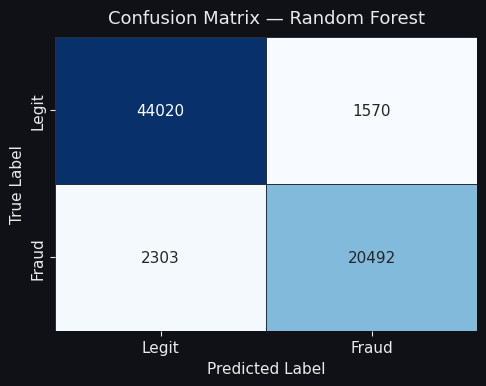

In [5]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5,
                              class_weight='balanced', n_jobs=-1, random_state=42)
rf = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test, COLORS[1])

## ⚡ Model 3 — XGBoost Classifier

### What
A gradient-boosting framework that builds an additive ensemble of decision trees sequentially, minimising a regularised loss function.

### Why include it
XGBoost has dominated **tabular fraud detection benchmarks** since 2016. Unlike Random Forest (which uses parallel independent trees), XGBoost builds each tree to **correct the errors of the previous one**, producing a highly accurate and well-calibrated model. It also natively handles missing values — critical for this dataset's many sparse V-features.

Training XGBoost ...
  Accuracy : 0.9652  |  F1 (macro) : 0.9600  |  ROC-AUC : 0.9858
              precision    recall  f1-score   support

  Legitimate       0.96      0.99      0.97     45590
  Fraudulent       0.99      0.91      0.95     22795

    accuracy                           0.97     68385
   macro avg       0.97      0.95      0.96     68385
weighted avg       0.97      0.97      0.96     68385

  Saved → reports/figures/basic_models/cm_xgboost.png


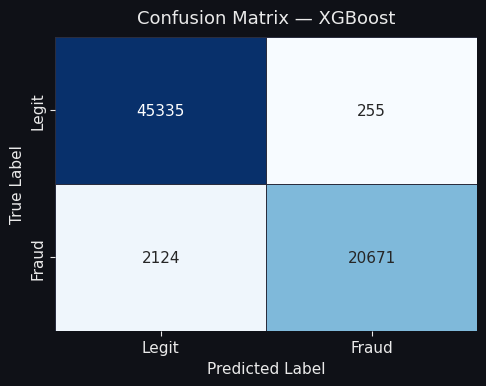

In [6]:
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    scale_pos_weight=1,  # already balanced via SMOTE
    random_state=42, n_jobs=-1
)
xgb = evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test, COLORS[2])

## 📊 Model Comparison — ROC Curves & Metric Summary

### What
Side-by-side comparison of all three models on a single ROC curve plot, plus a grouped bar chart comparing Accuracy, F1, and AUC-ROC.

### Why
A single chart communicates the relative strengths of each model instantly:
- The model with the **highest AUC** is best at ranking fraud above legit transactions (threshold-independent).
- The model with the **highest F1** is the best balanced performer at the default 0.5 threshold.
- The ROC curve shape reveals which model performs better at **low false-positive rates** — critical in fraud where false alarms waste investigator time.

  Saved → reports/figures/basic_models/basic_model_comparison.png


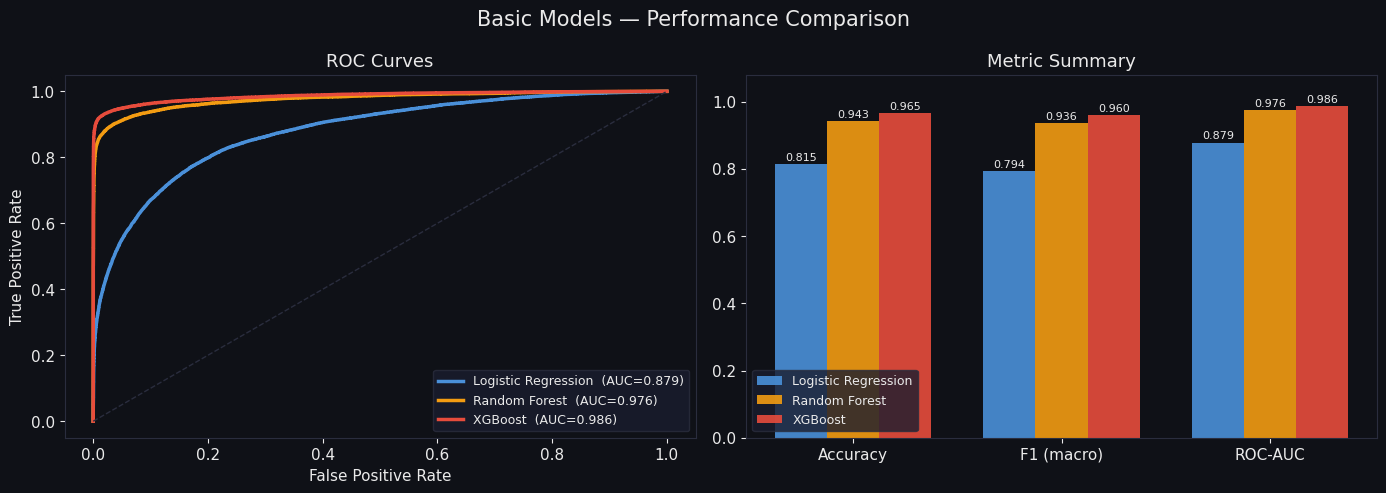


── Basic Model Results ──────────────────────────────
              Model Accuracy F1 (macro) ROC-AUC
Logistic Regression   0.8148     0.7940  0.8785
      Random Forest   0.9434     0.9358  0.9762
            XGBoost   0.9652     0.9600  0.9858


In [7]:
# ── ROC Curve comparison ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Basic Models — Performance Comparison', fontsize=15)

for (name, res), col in zip(results_store.items(), COLORS):
    ax1.plot(res['fpr'], res['tpr'], color=col, linewidth=2.5,
             label=f"{name}  (AUC={res['auc']:.3f})")
ax1.plot([0,1],[0,1], '--', color=GRID, linewidth=1)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves'); ax1.legend(fontsize=9)

# ── Metric bar chart ───────────────────────────────────────────────────────────
metrics = ['acc', 'f1', 'auc']
labels  = ['Accuracy', 'F1 (macro)', 'ROC-AUC']
names   = list(results_store.keys())
x = np.arange(len(metrics)); w = 0.25
for i, (name, col) in enumerate(zip(names, COLORS)):
    vals = [results_store[name][m] for m in metrics]
    bars = ax2.bar(x + i*w, vals, w, label=name, color=col, edgecolor='none', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, color=TEXT)
ax2.set_xticks(x + w); ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1.08); ax2.set_title('Metric Summary'); ax2.legend(fontsize=9)

fig.tight_layout()
savefig(fig, 'basic_model_comparison.png')

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': n, 'Accuracy': f"{r['acc']:.4f}", 'F1 (macro)': f"{r['f1']:.4f}", 'ROC-AUC': f"{r['auc']:.4f}"}
    for n, r in results_store.items()
])
print('\n── Basic Model Results ──────────────────────────────')
print(summary.to_string(index=False))

## 🔍 Feature Importance — Random Forest & XGBoost

Both tree-based models provide built-in feature importance metrics. These tell us which features
the models rely on most heavily — crucial information for the report and for feature selection.

  Saved → reports/figures/basic_models/basic_feature_importance.png


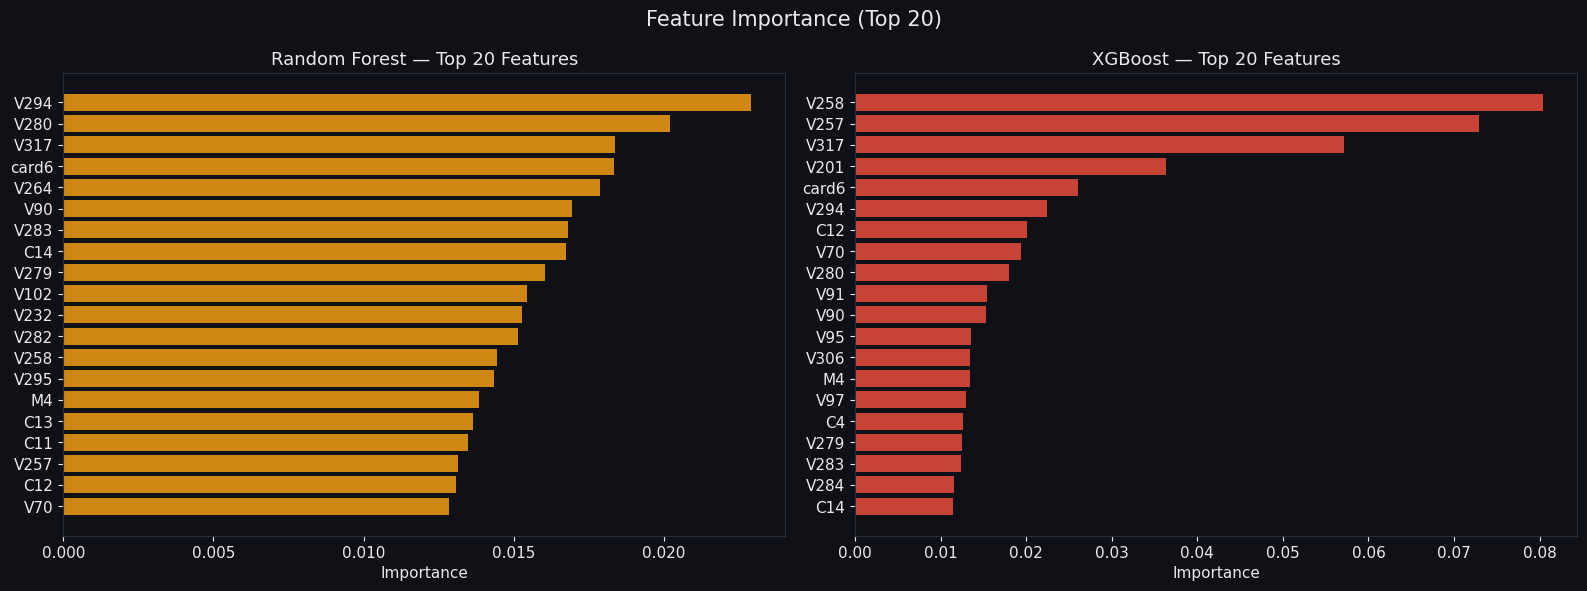

In [8]:
feat_names = X_train.columns.tolist()
fig, axes  = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance (Top 20)', fontsize=15)

for ax, model, name, col in [
    (axes[0], rf,  'Random Forest', COLORS[1]),
    (axes[1], xgb, 'XGBoost',       COLORS[2]),
]:
    importances = pd.Series(model.feature_importances_, index=feat_names)
    top20 = importances.sort_values(ascending=True).tail(20)
    ax.barh(top20.index, top20.values, color=col, edgecolor='none', alpha=0.85)
    ax.set_title(f'{name} — Top 20 Features')
    ax.set_xlabel('Importance')

fig.tight_layout()
savefig(fig, 'basic_feature_importance.png')